# UTS Prediksi Modern & Machine Learning
## Experiment Challenge: Credit Default Prediction

Dataset: Default of Credit Card Clients (Kaggle, UCI ML) | Target: `default.payment.next.month` | Metrik utama: F1-score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

# Experiment 0: Data Understanding & Preparation
## 0.1 Membaca dataset

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 0.2 Dimensi, struktur, dan tipe data

In [3]:
print("Dimensi:", df.shape)
df.info()
df.describe().T

Dimensi: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2 

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


**Temuan:** dataset berisi 30.000 baris dan 25 kolom, terdiri dari 1 kolom `ID`, 23 kolom calon prediktor, dan 1 kolom target. Seluruh kolom bertipe numerik (12 `int64`, 13 `float64`), sehingga tidak ada kolom teks yang perlu di-encode secara teknis. Kolom `SEX`, `EDUCATION`, `MARRIAGE`, dan `PAY_*` tetap berupa kode kategori meskipun bertipe angka.

## 0.3 Identifikasi variabel target

In [4]:
target = "default.payment.next.month"
print("Target     :", target)
print("Tipe data  :", df[target].dtype)
print("Nilai unik :", sorted(df[target].unique()), "(0 = tidak default, 1 = default)")

Target     : default.payment.next.month
Tipe data  : int64
Nilai unik : [np.int64(0), np.int64(1)] (0 = tidak default, 1 = default)


## 0.4 Missing value dan duplicate

In [5]:
print("Total missing value:", df.isnull().sum().sum())

n_dup = df.drop(columns="ID").duplicated().sum()
print(f"Duplicate (tanpa ID): {n_dup} baris ({n_dup/len(df)*100:.2f}%)")

Total missing value: 0
Duplicate (tanpa ID): 35 baris (0.12%)


**Temuan:** tidak ada missing value, jadi imputasi tidak diperlukan. Ada 35 baris duplikat (±0,12% dari data) setelah `ID` dikeluarkan (`ID` selalu unik sehingga harus diabaikan saat mengecek duplikat). Duplikat **dipertahankan** karena jumlahnya sangat kecil sehingga dampaknya ke model diabaikan, dan dua nasabah berbeda bisa saja memiliki profil yang identik.

## 0.5 Nilai tidak sesuai / tidak wajar

In [6]:
# Variabel kategorikal
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"\n{col}:\n", df[col].value_counts().sort_index())

# Status pembayaran
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
print("\nNilai unik PAY_*:", sorted(int(v) for v in pd.unique(df[pay_cols].values.ravel())))

# Variabel numerik
bill_cols    = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
print("\nLIMIT_BAL min/max:", df["LIMIT_BAL"].min(), "/", df["LIMIT_BAL"].max())
print("AGE min/max      :", df["AGE"].min(), "/", df["AGE"].max())
print("LIMIT_BAL <= 0   :", (df["LIMIT_BAL"] <= 0).sum())
print("AGE < 18 / > 100 :", ((df["AGE"] < 18) | (df["AGE"] > 100)).sum())
print("PAY_AMT negatif  :", (df[pay_amt_cols] < 0).sum().sum())
print("BILL_AMT negatif :", (df[bill_cols] < 0).sum().to_dict())

# Kategori di luar dokumentasi
print("\nEDUCATION di luar 1-4:", (~df["EDUCATION"].isin([1, 2, 3, 4])).sum())
print("MARRIAGE di luar 1-3 :", (~df["MARRIAGE"].isin([1, 2, 3])).sum())


SEX:
 SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION:
 EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE:
 MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Nilai unik PAY_*: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

LIMIT_BAL min/max: 10000.0 / 1000000.0
AGE min/max      : 21 / 79
LIMIT_BAL <= 0   : 0
AGE < 18 / > 100 : 0
PAY_AMT negatif  : 0
BILL_AMT negatif : {'BILL_AMT1': 590, 'BILL_AMT2': 669, 'BILL_AMT3': 655, 'BILL_AMT4': 675, 'BILL_AMT5': 655, 'BILL_AMT6': 688}

EDUCATION di luar 1-4: 345
MARRIAGE di luar 1-3 : 54


**Temuan dan keputusan:**

| Variabel | Temuan | Keputusan |
|---|---|---|
| `EDUCATION` | Ada nilai 0 (14), 5 (280), 6 (51) = 345 baris di luar kode dokumentasi 1-4 | Digabung ke kategori 4 (others) |
| `MARRIAGE` | Ada nilai 0 (54 baris), di luar kode 1-3 | Digabung ke kategori 3 (others) |
| `PAY_*` | Bernilai -2 sampai 8, padahal dokumentasi hanya -1 dan 1-9 | Dipertahankan, karena -2 (tidak ada tagihan) dan 0 (revolving credit) membawa informasi status pembayaran |
| `BILL_AMT1-6` | Ada nilai negatif (590-688 baris per kolom) | Dipertahankan, wajar karena kelebihan bayar |
| `LIMIT_BAL`, `AGE`, `PAY_AMT*` | Tidak ada nilai ≤ 0 atau di luar rentang wajar (usia 21-79) | Tidak ada tindakan |
| `PAY_0` | Penamaan tidak konsisten dengan `PAY_2`...`PAY_6` | Di-rename menjadi `PAY_1` |

Nilai ekstrem pada `BILL_AMT` dan `PAY_AMT` (maksimum jauh di atas persentil 75) tidak dibuang karena masih masuk akal untuk nasabah dengan limit besar (hingga 1.000.000).

## 0.6 Distribusi variabel target

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


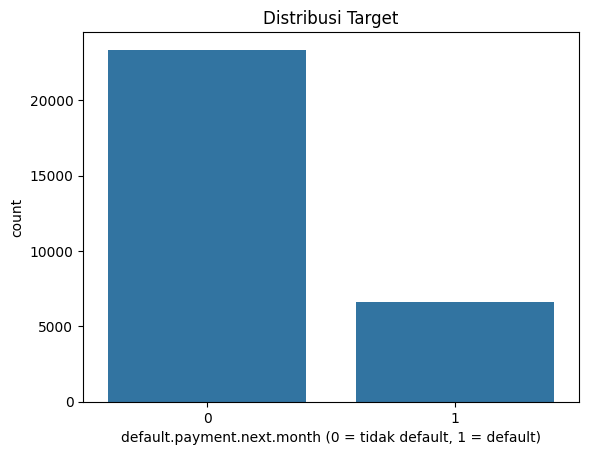

In [7]:
print(df[target].value_counts())
print(df[target].value_counts(normalize=True).round(4))

sns.countplot(x=target, data=df)
plt.title("Distribusi Target")
plt.xlabel("default.payment.next.month (0 = tidak default, 1 = default)")
plt.show()

**Temuan:** kelas tidak seimbang, yaitu 23.364 nasabah tidak default (77,88%) dan 6.636 default (22,12%). Konsekuensinya, accuracy bisa menyesatkan (model yang selalu menebak "tidak default" sudah mendapat ±78%), sehingga **F1-score dipakai sebagai metrik utama**, sesuai ketentuan soal. Untuk menjaga proporsi kelas, split memakai `stratify=y`.

## 0.7 Menentukan predictor & target, mengeluarkan ID

In [8]:
X = df.drop(columns=["ID", target])   # ID dikeluarkan dari predictor
y = df[target]

print("Jumlah predictor:", X.shape[1])
print("Predictor:", list(X.columns))

Jumlah predictor: 23
Predictor: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


**Keputusan:** `ID` dikeluarkan karena hanya nomor urut tanpa makna prediktif (sesuai soal). Tersisa **23 predictor**; target adalah `default.payment.next.month`.

## 0.8 Train-test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporsi default train:", y_train.mean().round(4))
print("Proporsi default test :", y_test.mean().round(4))

Train: (24000, 23) | Test: (6000, 23)
Proporsi default train: 0.2212
Proporsi default test : 0.2212


**Keputusan:** split 80:20 (24.000 train, 6.000 test) dilakukan **sebelum** preprocessing apa pun agar tidak ada kebocoran informasi dari test set. `stratify=y` menjaga proporsi default tetap 22,12% di kedua set, dan `random_state=42` membuat hasil dapat direproduksi.

## 0.9 Preprocessing (data cleaning)

In [10]:
def clean_data(d):
    d = d.copy()
    # EDUCATION: 0, 5, 6 tidak terdokumentasi -> gabung ke 4 (others)
    d["EDUCATION"] = d["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    # MARRIAGE: 0 tidak terdokumentasi -> gabung ke 3 (others)
    d["MARRIAGE"] = d["MARRIAGE"].replace({0: 3})
    # PAY_0 -> PAY_1 supaya konsisten dengan PAY_2..PAY_6
    d = d.rename(columns={"PAY_0": "PAY_1"})
    return d

X_train = clean_data(X_train)
X_test  = clean_data(X_test)

# Verifikasi
for col in ["EDUCATION", "MARRIAGE"]:
    print(col, "| train:", sorted(X_train[col].unique()), "| test:", sorted(X_test[col].unique()))
print("Missing train/test:", X_train.isnull().sum().sum(), "/", X_test.isnull().sum().sum())
print("Kolom:", list(X_train.columns))

EDUCATION | train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | test: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE | train: [np.int64(1), np.int64(2), np.int64(3)] | test: [np.int64(1), np.int64(2), np.int64(3)]
Missing train/test: 0 / 0
Kolom: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## Ringkasan Experiment 0

- **Data:** 30.000 observasi, 23 predictor numerik, 1 target biner. Tidak ada missing value; 35 duplikat (0,12%) dipertahankan.
- **Preprocessing yang dilakukan:** (1) `EDUCATION` 0/5/6 digabung ke 4, (2) `MARRIAGE` 0 digabung ke 3, (3) `PAY_0` di-rename menjadi `PAY_1`. Aturan ini bersifat tetap (tidak dihitung dari data) sehingga aman dari data leakage walaupun diterapkan ke train dan test.
- **Preprocessing yang sengaja belum dilakukan:** feature scaling dan encoding. Keduanya akan diterapkan dan diukur dampaknya pada **Experiment 2** (di dalam `Pipeline` agar fit hanya pada data training tiap fold CV), sehingga baseline Experiment 1 tetap menjadi pembanding yang bersih.
- **Catatan imbalance:** kelas default hanya 22,12%, jadi F1-score menjadi metrik utama dan accuracy hanya pendukung.
- **Data siap pakai:** `X_train`, `X_test`, `y_train`, `y_test`.

# Experiment 1: Baseline Model
Logistic Regression sebagai baseline. Data yang dipakai adalah `X_train` dan `X_test` hasil cleaning Experiment 0, tanpa scaling dan encoding. Evaluasi: 5-fold Stratified CV pada training set (metrik F1) dan evaluasi pada test set.

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []   # menampung hasil semua eksperimen untuk tabel ringkasan final

def evaluate(model, X_tr, y_tr, X_te, y_te, exp, name):
    # 5-fold CV pada training set (metrik utama: F1)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="f1", n_jobs=-1)

    # fit pada seluruh training set, lalu evaluasi pada test set
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    res = {
        "Experiment": exp,
        "Model": name,
        "CV F1": cv_scores.mean(),
        "CV F1 Std": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_te, pred),
        "Test Precision": precision_score(y_te, pred, zero_division=0),
        "Test Recall": recall_score(y_te, pred),
        "Test F1": f1_score(y_te, pred),
    }
    results.append(res)
    return res, pred

In [13]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

res1, pred1 = evaluate(baseline, X_train, y_train, X_test, y_test,
                       exp=1, name="Logistic Regression (baseline)")

display(pd.DataFrame([res1]).round(4))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Experiment,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Logistic Regression (baseline),0.3367,0.0493,0.8082,0.6648,0.2675,0.3815


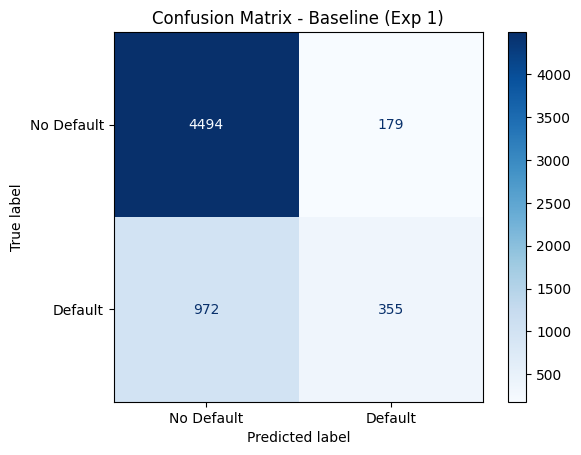

In [14]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred1),
    display_labels=["No Default", "Default"]
).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Baseline (Exp 1)")
plt.show()

## Hasil Experiment 1

| Metrik | Nilai |
|---|---|
| CV F1-score (5-fold) | 0,3367 (± 0,0493) |
| Test Accuracy | 0,8082 |
| Test Precision | 0,6648 |
| Test Recall | 0,2675 |
| Test F1-score | 0,3815 |

**Interpretasi:** Accuracy terlihat tinggi (80,8%), tetapi hanya sedikit di atas model yang selalu menebak "tidak default" (77,88%). F1-score rendah (0,38) karena recall hanya 0,27: dari 1.327 nasabah default di test set, hanya 355 yang terdeteksi dan 972 terlewat (false negative). Precision relatif lebih baik (0,66), artinya model cukup yakin saat memprediksi default, tetapi terlalu konservatif. Hal ini sesuai dengan kondisi kelas tidak seimbang (22,12% default). CV F1 (0,337) dan Test F1 (0,382) berdekatan, sehingga tidak ada indikasi overfitting. Muncul `ConvergenceWarning` pada lbfgs karena fitur belum di-scale (rentang `BILL_AMT` hingga jutaan vs `PAY_*` -2 sampai 8), yang menjadi motivasi Experiment 2. Hasil ini menjadi baseline.

# Experiment 2: Preprocessing
Logistic Regression yang sama dengan baseline (hyperparameter identik), tetapi dengan preprocessing di dalam `Pipeline`: `StandardScaler` untuk fitur numerik kontinu (`LIMIT_BAL`, `AGE`, `BILL_AMT1-6`, `PAY_AMT1-6`) dan `OneHotEncoder` untuk `SEX`, `EDUCATION`, `MARRIAGE`. Kolom `PAY_1-6` dibiarkan karena sudah berupa status ordinal berskala kecil. Pipeline memastikan transformer hanya di-fit pada data training di setiap fold (tanpa data leakage).

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = (["LIMIT_BAL", "AGE"]
            + [f"BILL_AMT{i}" for i in range(1, 7)]
            + [f"PAY_AMT{i}" for i in range(1, 7)])
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
pay_cols = [f"PAY_{i}" for i in range(1, 7)]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("pay", "passthrough", pay_cols),
    ]
)

lr_prep = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

res2, pred2 = evaluate(lr_prep, X_train, y_train, X_test, y_test,
                       exp=2, name="Logistic Regression + Preprocessing")
display(pd.DataFrame([res2]).round(4))

,Experiment,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,2,Logistic Regression + Preprocessing,0.3648,0.0152,0.809,0.693,0.2449,0.3619


,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,,,,,
1,0.3367,0.8082,0.6648,0.2675,0.3815
2,0.3648,0.8090,0.6930,0.2449,0.3619
Selisih (2 - 1),0.0282,0.0008,0.0282,-0.0226,-0.0196


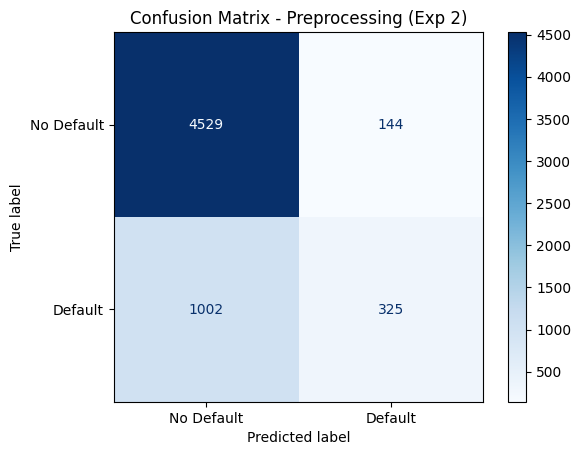

In [16]:
cmp = pd.DataFrame(results[:2]).set_index("Experiment")[
    ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
]
cmp.loc["Selisih (2 - 1)"] = cmp.loc[2] - cmp.loc[1]
display(cmp.round(4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred2),
    display_labels=["No Default", "Default"]
).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Preprocessing (Exp 2)")
plt.show()

## Hasil Experiment 2

| Metrik | Exp 1 (Baseline) | Exp 2 (+Preprocessing) | Selisih |
|---|---|---|---|
| CV F1-score | 0,3367 | 0,3648 | +0,0282 |
| Test Accuracy | 0,8082 | 0,8090 | +0,0008 |
| Test Precision | 0,6648 | 0,6930 | +0,0282 |
| Test Recall | 0,2675 | 0,2449 | -0,0226 |
| Test F1-score | 0,3815 | 0,3619 | -0,0196 |

**Apakah preprocessing meningkatkan performa?** Hasilnya campuran. CV F1 naik dari 0,3367 menjadi 0,3648 dan simpangan baku antar fold turun dari 0,0493 menjadi 0,0152, artinya model lebih stabil dan optimisasi konvergen (tidak ada lagi `ConvergenceWarning`). Namun Test F1 turun dari 0,3815 menjadi 0,3619 karena recall turun (0,2675 menjadi 0,2449) walaupun precision naik (0,6648 menjadi 0,6930). Selisih Test F1 sebesar 0,02 relatif kecil dibandingkan variasi antar fold pada baseline, sehingga tidak dapat disimpulkan sebagai penurunan yang bermakna. Kesimpulannya, preprocessing meningkatkan stabilitas dan CV F1, tetapi tidak meningkatkan kemampuan mendeteksi nasabah default pada test set; kelemahan utama (recall rendah akibat ketidakseimbangan kelas) tidak diatasi oleh scaling dan encoding. Preprocessing tetap dipakai pada eksperimen berikutnya karena CV (5 fold) merupakan estimasi yang lebih andal daripada satu test set.

# Experiment 3: Model Comparison
Tiga model dibandingkan dengan prosedur evaluasi yang sama: preprocessing pipeline yang sama (dari Experiment 2), 5-fold Stratified CV pada training set, lalu evaluasi pada test set. Model terbaik dipilih berdasarkan hasil evaluasi (CV F1 sebagai acuan utama, didukung Test F1), bukan asumsi.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

fitted3, preds3 = {}, {}
for name, clf in models.items():
    pipe = Pipeline([("prep", clone(preprocessor)), ("clf", clf)])
    res, pred = evaluate(pipe, X_train, y_train, X_test, y_test, exp=3, name=name)
    fitted3[name], preds3[name] = pipe, pred

exp3 = pd.DataFrame([r for r in results if r["Experiment"] == 3]).set_index("Model")
display(exp3[["CV F1", "CV F1 Std", "Test Accuracy", "Test Precision",
              "Test Recall", "Test F1"]].round(4))

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
Model,,,,,,
Logistic Regression,0.3648,0.0152,0.8090,0.6930,0.2449,0.3619
Decision Tree,0.3966,0.0088,0.7225,0.3791,0.3994,0.3890
Random Forest,0.4769,0.0063,0.8163,0.6502,0.3670,0.4692


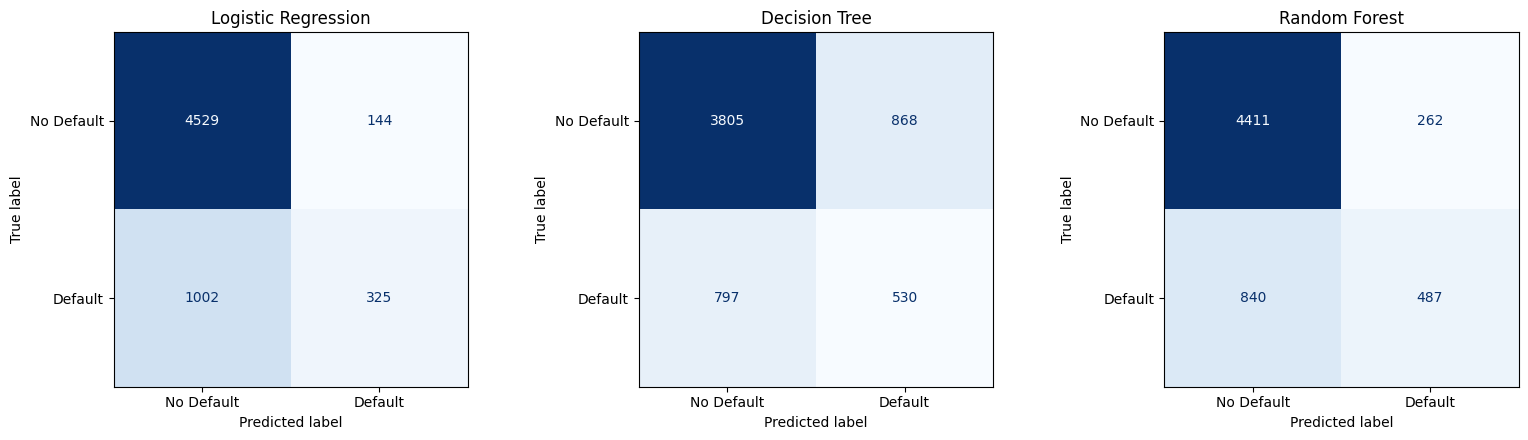

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pred) in zip(axes, preds3.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["No Default", "Default"]
                           ).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Hasil Experiment 3

| Model | CV F1 | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---|---|---|---|---|---|
| Logistic Regression | 0,3648 | 0,8090 | 0,6930 | 0,2449 | 0,3619 |
| Decision Tree | 0,3966 | 0,7225 | 0,3791 | 0,3994 | 0,3890 |
| Random Forest | 0,4769 | 0,8163 | 0,6502 | 0,3670 | 0,4692 |

**Model terbaik: Random Forest.** Random Forest unggul pada CV F1 (0,4769 dibanding 0,3966 untuk Decision Tree dan 0,3648 untuk Logistic Regression) dengan simpangan baku antar fold paling kecil (0,0063), dan hasil itu terkonfirmasi di test set (Test F1 0,4692, Test Accuracy 0,8163, tertinggi di antara ketiga model). Decision Tree memiliki recall tertinggi (0,3994) tetapi precision-nya hanya 0,3791 dan accuracy turun ke 0,7225, karena pohon tanpa batas kedalaman cenderung overfit dan banyak salah menandai nasabah baik sebagai default (868 kasus). Logistic Regression memiliki precision tertinggi (0,6930) tetapi recall terendah (0,2449), sehingga banyak nasabah default yang terlewat. Random Forest memberi keseimbangan terbaik antara precision dan recall, sehingga dipilih untuk Experiment 4.

# Experiment 4: Hyperparameter Tuning
Model terbaik dari Experiment 3 (Random Forest) di-tuning dengan `GridSearchCV` (5-fold Stratified CV, scoring F1). Preprocessor tetap berada di dalam `Pipeline` sehingga tidak terjadi data leakage selama pencarian.

In [19]:
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [10, 20, None],
    "clf__min_samples_leaf": [1, 2, 5],
    "clf__class_weight": [None, "balanced"],
}

# Mengubah n_jobs=-1 di GridSearchCV agar pencarian hyperparameter berjalan paralel di semua core CPU
grid = GridSearchCV(rf_pipe, param_grid, cv=cv, scoring="f1",
                    n_jobs=-1, refit=True, verbose=1)
grid.fit(X_train, y_train)

print("Hyperparameter terbaik:", grid.best_params_)
print("Best CV F1            :", round(grid.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Hyperparameter terbaik: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
Best CV F1            : 0.5453


,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Model,,,,,
Random Forest,0.4769,0.8163,0.6502,0.3670,0.4692
Random Forest (tuned),0.5453,0.7907,0.5248,0.5652,0.5443
Selisih (tuned - default),0.0684,-0.0257,-0.1254,0.1982,0.0751


,param_clf__n_estimators,param_clf__max_depth,param_clf__min_samples_leaf,param_clf__class_weight,mean_test_score,std_test_score
21,200,10,2,balanced,0.5453,0.0068
19,200,10,1,balanced,0.5442,0.0065
18,100,10,1,balanced,0.5441,0.0075
22,100,10,5,balanced,0.5435,0.0075
20,100,10,2,balanced,0.5435,0.0043


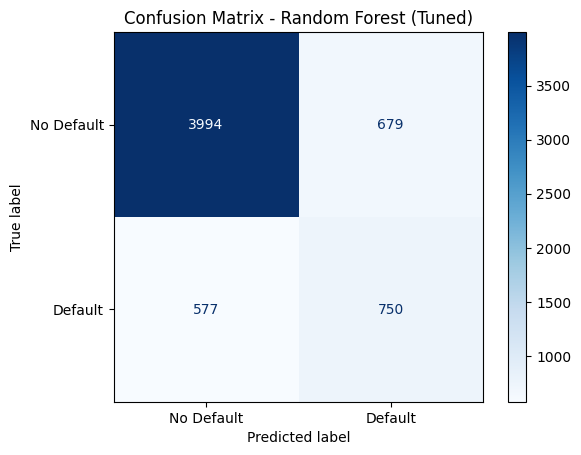

In [20]:
res4, pred4 = evaluate(clone(grid.best_estimator_), X_train, y_train, X_test, y_test,
                       exp=4, name="Random Forest (tuned)")

before = [r for r in results if r["Experiment"] == 3 and r["Model"] == "Random Forest"][0]
cmp4 = pd.DataFrame([before, res4]).set_index("Model")[
    ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]]
cmp4.loc["Selisih (tuned - default)"] = cmp4.iloc[1] - cmp4.iloc[0]
display(cmp4.round(4))

# 5 kombinasi terbaik
cvr = pd.DataFrame(grid.cv_results_)
cols = ["param_clf__n_estimators", "param_clf__max_depth",
        "param_clf__min_samples_leaf", "param_clf__class_weight",
        "mean_test_score", "std_test_score"]
display(cvr.sort_values("mean_test_score", ascending=False)[cols].head(5).round(4))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred4),
                       display_labels=["No Default", "Default"]
                       ).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.show()

## Hasil Experiment 4

**Hyperparameter yang diuji (36 kombinasi x 5-fold CV = 180 fit):** `n_estimators` {100, 200}, `max_depth` {10, 20, None}, `min_samples_leaf` {1, 2, 5}, `class_weight` {None, balanced}.

**Kombinasi terbaik:** `n_estimators=200`, `max_depth=10`, `min_samples_leaf=2`, `class_weight='balanced'` dengan best CV F1 = 0,5453.

| Metrik | RF sebelum tuning | RF setelah tuning | Selisih |
|---|---|---|---|
| CV F1-score | 0,4769 | 0,5453 | +0,0684 |
| Test Accuracy | 0,8163 | 0,7907 | -0,0257 |
| Test Precision | 0,6502 | 0,5248 | -0,1254 |
| Test Recall | 0,3670 | 0,5652 | +0,1982 |
| Test F1-score | 0,4692 | 0,5443 | +0,0751 |

**Apakah tuning meningkatkan performa?** Ya. F1-score naik pada CV (+0,0684) dan pada test set (+0,0751), jauh melebihi simpangan baku antar fold (sekitar 0,007). Lima kombinasi teratas semuanya memakai `class_weight='balanced'` dan `max_depth=10` dengan selisih skor yang sangat kecil, sehingga kedua hyperparameter inilah yang paling berpengaruh, sedangkan `n_estimators` dan `min_samples_leaf` nyaris tidak berpengaruh. Peningkatan ini berasal dari pergeseran trade-off: recall naik dari 0,3670 menjadi 0,5652 (lebih banyak nasabah default terdeteksi), tetapi precision turun dari 0,6502 menjadi 0,5248 dan accuracy turun 0,0257 karena lebih banyak nasabah baik yang salah ditandai default. Karena F1 adalah metrik utama dan recall adalah kelemahan utama pada eksperimen sebelumnya, trade-off ini dinilai menguntungkan. Keterbatasan: `max_depth=10` merupakan nilai terkecil pada grid, sehingga kedalaman yang lebih kecil belum diuji.

# Experiment 5: Advanced Model
XGBoost (gradient boosting) dievaluasi dengan prosedur yang sama (preprocessing pipeline, 5-fold Stratified CV, evaluasi test set). Dua varian dibandingkan: tanpa dan dengan `scale_pos_weight` (rasio kelas negatif:positif pada data training) agar perbandingan dengan Random Forest tuned (yang memakai `class_weight='balanced'`) adil. Hyperparameter ditetapkan moderat dan tidak di-tuning.

In [21]:
# !pip install xgboost
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(spw, 3))

def make_xgb(**kw):
    return Pipeline([
        ("prep", clone(preprocessor)),
        ("clf", XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, **kw)),
    ])

xgb_variants = {
    "XGBoost (default weight)": make_xgb(),
    "XGBoost (scale_pos_weight)": make_xgb(scale_pos_weight=spw),
}

preds5 = {}
for name, pipe in xgb_variants.items():
    res, pred = evaluate(pipe, X_train, y_train, X_test, y_test, exp=5, name=name)
    preds5[name] = pred

exp5 = pd.DataFrame([r for r in results if r["Experiment"] == 5]).set_index("Model")
rf_tuned = [r for r in results if r["Experiment"] == 4][0]
cmp5 = pd.concat([pd.DataFrame([rf_tuned]).set_index("Model"), exp5])
display(cmp5[["CV F1", "CV F1 Std", "Test Accuracy", "Test Precision",
              "Test Recall", "Test F1"]].round(4))

scale_pos_weight: 3.521


,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
Model,,,,,,
Random Forest (tuned),0.5453,0.0068,0.7907,0.5248,0.5652,0.5443
XGBoost (default weight),0.4795,0.0069,0.8190,0.6690,0.3595,0.4676
XGBoost (scale_pos_weight),0.5420,0.0100,0.7607,0.4687,0.6149,0.5319


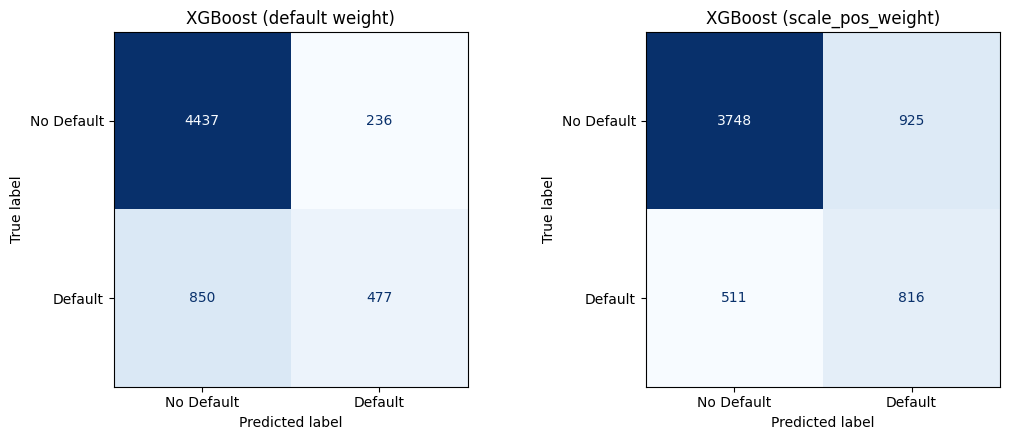

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, preds5.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["No Default", "Default"]
                           ).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Hasil Experiment 5

`scale_pos_weight` dihitung dari data training (rasio negatif:positif = 3,521). Varian yang dipakai untuk perbandingan final dipilih berdasarkan CV F1.

| Model | CV F1 | Test Accuracy | Test Precision | Test Recall | Test F1 |
|---|---|---|---|---|---|
| Random Forest (tuned, Exp 4) | 0,5453 | 0,7907 | 0,5248 | 0,5652 | 0,5443 |
| XGBoost (default weight) | 0,4795 | 0,8190 | 0,6690 | 0,3595 | 0,4676 |
| XGBoost (scale_pos_weight) | 0,5420 | 0,7607 | 0,4687 | 0,6149 | 0,5319 |

**Apakah model advanced lebih baik?** Tidak. XGBoost dengan `scale_pos_weight` mencapai CV F1 0,5420 dan Test F1 0,5319, sedikit di bawah Random Forest tuned (0,5453 dan 0,5443). Selisih CV F1 (0,0033) lebih kecil dari simpangan baku antar fold, sehingga keduanya setara pada CV, dan pada test set Random Forest tuned tetap lebih tinggi. XGBoost tanpa pembobotan kelas (CV F1 0,4795) nyaris sama dengan Random Forest default (0,4769), sehingga peningkatan pada Experiment 4 dan 5 terutama berasal dari penanganan ketidakseimbangan kelas, bukan dari kompleksitas algoritma. Keterbatasan: XGBoost tidak di-tuning, sehingga potensi performanya belum sepenuhnya diuji.

In [24]:
exp5_best = (pd.DataFrame([r for r in results if r["Experiment"] == 5])
             .sort_values("CV F1", ascending=False).iloc[0]["Model"])  # dipilih via CV F1

pilihan = {
    1: "Logistic Regression (baseline)",
    2: "Logistic Regression + Preprocessing",
    3: "Random Forest",           # model terbaik Exp 3
    4: "Random Forest (tuned)",
    5: exp5_best,
}
label = {1: "Baseline", 2: "Baseline + Preprocessing", 3: "Model Comparison (terbaik)",
         4: "Tuned Model", 5: "Advanced Model"}

summary = pd.DataFrame([r for r in results
                        if pilihan.get(r["Experiment"]) == r["Model"]])
summary["Experiment"] = summary["Experiment"].map(lambda e: f"{e} - {label[e]}")
display(summary[["Experiment", "Model", "CV F1", "Test Accuracy",
                 "Test Precision", "Test Recall", "Test F1"]].round(4))

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1 - Baseline,Logistic Regression (baseline),0.3367,0.8082,0.6648,0.2675,0.3815
1,2 - Baseline + Preprocessing,Logistic Regression + Preprocessing,0.3648,0.8090,0.6930,0.2449,0.3619
2,3 - Model Comparison (terbaik),Random Forest,0.4769,0.8163,0.6502,0.3670,0.4692
3,4 - Tuned Model,Random Forest (tuned),0.5453,0.7907,0.5248,0.5652,0.5443
4,5 - Advanced Model,XGBoost (scale_pos_weight),0.5420,0.7607,0.4687,0.6149,0.5319
